# Question 3 – Audio Similarity Using Pretrained Embeddings (YAMNet)

## 1. Install Dependencies

In [15]:
!pip install --user tensorflow tensorflow_hub tensorflow_io librosa matplotlib scikit-learn soundfile -q


[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Import Libraries

In [16]:
import os
import numpy as np
import librosa, librosa.display
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.decomposition import PCA
from IPython.display import Audio, display


## 3. Load Dataset

In [17]:
DATASET_PATH='../datasets/speech_commands'
audio_files=[]; labels=[]
for lbl in sorted(os.listdir(DATASET_PATH)):
    d=os.path.join(DATASET_PATH,lbl)
    if os.path.isdir(d) and not lbl.startswith('_'):
        wav=[f for f in os.listdir(d) if f.endswith('.wav')]
        if wav:
            audio_files.append(os.path.join(d,wav[0]))
            labels.append(lbl)
print(labels)


['backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero']


## 4. Load Pretrained YAMNet

In [18]:
model=hub.load('https://tfhub.dev/google/yamnet/1')


## 5. Extract Embeddings

In [19]:
emb=[]
for f in audio_files:
    y,sr=librosa.load(f,sr=16000)
    scores,e,spec=model(y)
    emb.append(tf.reduce_mean(e,axis=0).numpy())
emb=np.array(emb)
print(emb.shape)


(35, 1024)


## 6. Similarity and Distance

In [20]:
sim=cosine_similarity(emb)
dist=euclidean_distances(emb)

## 7. Heatmaps

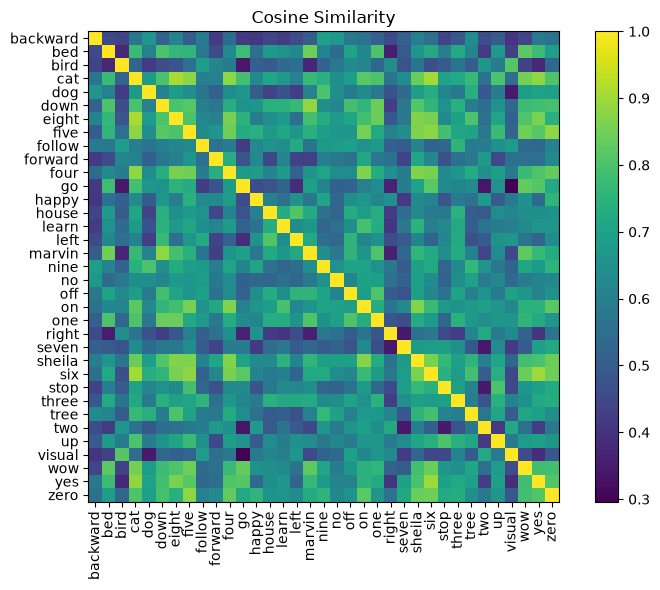

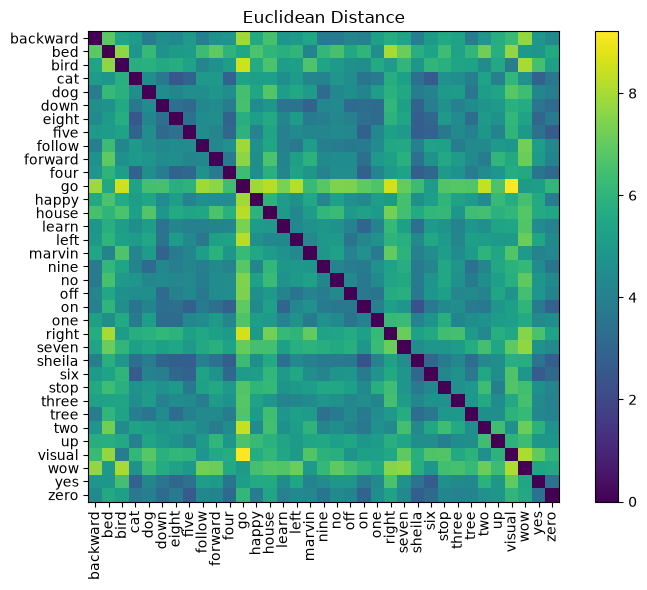

In [21]:
plt.figure(figsize=(8,6))
plt.imshow(sim)
plt.colorbar()
plt.xticks(range(len(labels)),labels,rotation=90)
plt.yticks(range(len(labels)),labels)
plt.title('Cosine Similarity')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
plt.imshow(dist)
plt.colorbar()
plt.xticks(range(len(labels)),labels,rotation=90)
plt.yticks(range(len(labels)),labels)
plt.title('Euclidean Distance')
plt.tight_layout()
plt.show()


## 8. PCA Visualization

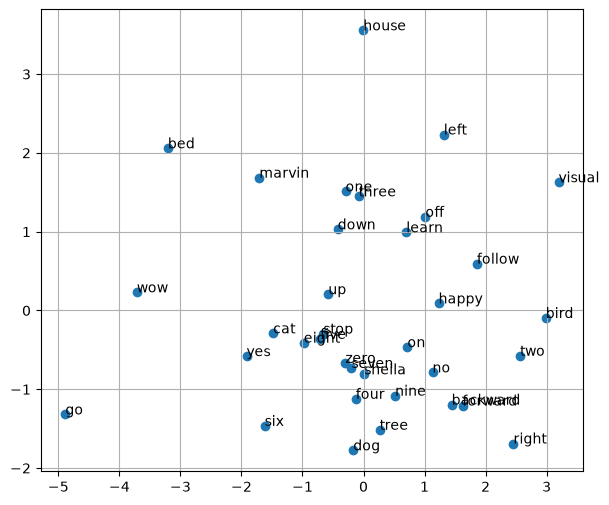

In [22]:
p=PCA(n_components=2).fit_transform(emb)
plt.figure(figsize=(7,6))
plt.scatter(p[:,0],p[:,1])
for i,l in enumerate(labels):
    plt.text(p[i,0],p[i,1],l)
plt.grid(True)
plt.show()


## Observations

- Extract embeddings using pretrained YAMNet.
- Compute cosine similarity and Euclidean distance.
- Visualize relationships using heatmaps and PCA.

## Conclusion

YAMNet embeddings enable meaningful comparison between speech recordings without additional training.
